In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the libraries for an EBM.

In [26]:
#| echo: true
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingClassifier

Loading a dataset.

In [22]:
#| echo: true
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Creating and fitting the model.

In [24]:
#| echo: true
ebm = ExplainableBoostingClassifier(
    interactions=0,
    outer_bags=1,
    max_bins=64,
    max_rounds=1000,
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42
)
ebm.fit(X_train, y_train)

ExplainableBoostingClassifier(interactions=0, learning_rate=0.05, max_bins=64,
                              max_rounds=1000, n_jobs=-1, outer_bags=1)

Plotting the contribution of the feature `mean radius`.

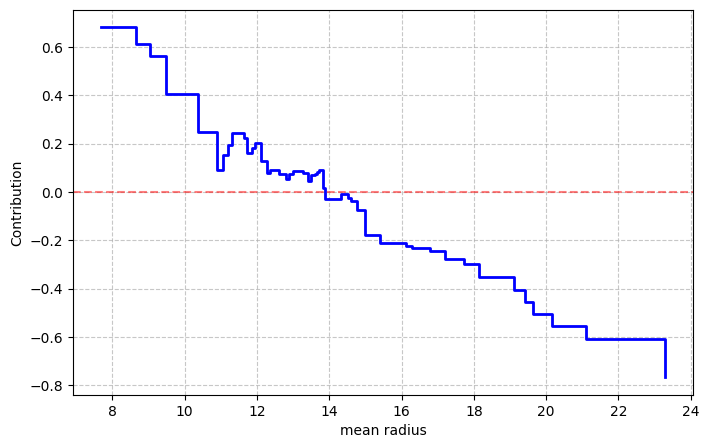

In [30]:
#| echo: true
feature_name = 'mean radius'
feature_idx = X.columns.get_loc(feature_name)

ebm_global = ebm.explain_global()
feature_data = ebm_global.data(feature_idx)

x_vals = feature_data['names']
y_vals = feature_data['scores']

plt.figure(figsize=(8, 5))

if len(x_vals) == len(y_vals) + 1:
    plt.step(x_vals[:-1], y_vals, where='post', color='blue', linewidth=2)
else:
    plt.plot(x_vals, y_vals, color='blue', linewidth=2)

if 'upper_bounds' in feature_data and 'lower_bounds' in feature_data:
    upper = feature_data['upper_bounds']
    lower = feature_data['lower_bounds']
    if len(x_vals) == len(upper) + 1:
        plt.fill_between(x_vals[:-1], lower, upper, alpha=0.2, color='blue', step='post')

plt.xlabel(feature_name)
plt.ylabel("Contribution")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

As depicted in the plot, lower values of the feature lead to higher probability of a benign tumor, while higher values increase the probability of malign tumors.